# 02_preprocessing — 前処理と特徴量生成

データ分析の世界では **「前処理が 8 割」** と言われるほど重要な工程です。
モデル精度は、ここで大きく決まります。

## このノートブックで扱う前処理

| # | 種類 | 目的 | 主な手法 |
|-|-|-|-|
| ① | **欠損値の処理** | モデルが学習できる形にする | 削除 (`drop`), `dropna`, `fillna` |
| ② | **カテゴリ変数のエンコーディング** | 文字列を数値に変換 | One-hot, Label encoding |
| ③ | **スケーリング** | 列ごとの尺度を揃える | 正規化 (MinMax), 標準化 (Standard) |
| ④ | **特徴量生成** | 既存列から新しい列を作る | ドメイン知識による組合せ |

## 前処理が必要な主な理由

1. 多くの機械学習モデルは **文字列ではなく数値** を受け取る (CatBoost のような例外もあり)
2. 欠損値があると学習できないモデルが多い (XGBoost のような例外もあり)
3. スケーリングしないと、距離ベースのアルゴリズム (k-NN, k-Means, SVM) や勾配降下法ベースのアルゴリズム (線形回帰, NN) の性能が落ちる
4. 既存の特徴量を組み合わせると、より予測に効く特徴量が作れることがある


In [1]:
# ===== プロジェクトの src/ を import できるようにする共通の準備 =====
# notebooks/ から見て1つ上の階層がプロジェクトルート (= data_analysis_project)
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print('PROJECT_ROOT =', PROJECT_ROOT)


PROJECT_ROOT = /Users/kenta.hoji.ea/Desktop/pythonデータ分析/data_analysis_project


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

from src import data_loader, preprocessing, features

%matplotlib inline
sns.set_theme(style='whitegrid')


## データ読み込み

In [3]:
df = data_loader.load_raw()
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## ① 欠損値の処理

欠損値があると、ほとんどの機械学習モデルはエラーになります。
pandas では欠損は `NaN` (Not a Number) として表現され、次の 3 つの戦略が代表的です。

### 戦略 1: 削除 (drop / dropna)

`drop` は **行/列を指定して削除**。
`dropna` は **欠損がある行/列をまとめて削除**。


#### 欠損自体に意味があるかを考える

欠損値を機械的に削除/補完する前に「**なぜ欠損したか**」 を考える必要があります。

- **セレクションバイアス**: 特定の条件のデータが入手されにくい (例: 特定年齢層がアンケートに答えない)
- **時間依存の欠損**: 機器の故障で一定期間のデータが落ちる

意味のある欠損を機械的に処理すると、モデルが誤った情報を学習してしまいます。


In [4]:
# 元データには欠損がないので、説明用にダミーデータを作成
d = {
    'name':  ['Sato', np.nan, 'Tanaka', 'Suzuki'],
    'age':   [24, 30, np.nan, 22],
    'state': ['Tokyo', 'Osaka', 'Kyoto', np.nan],
    'other': [np.nan, np.nan, np.nan, np.nan],
}
sample = pd.DataFrame(d)
sample


,name,age,state,other
0,Sato,24.0,Tokyo,NaN
1,NaN,30.0,Osaka,NaN
2,Tanaka,NaN,Kyoto,NaN
3,Suzuki,22.0,NaN,NaN


In [5]:
# 列ごとの欠損数
sample.isnull().sum()


name     1
age      1
state    1
other    4
dtype: int64

**drop による削除**

In [6]:
# 2 行目 (index=1) を削除
sample.drop(index=1)


,name,age,state,other
0,Sato,24.0,Tokyo,NaN
2,Tanaka,NaN,Kyoto,NaN
3,Suzuki,22.0,NaN,NaN


In [7]:
# 'other' 列を削除 (全部欠損なので消したい)
sample.drop(columns='other')


,name,age,state
0,Sato,24.0,Tokyo
1,NaN,30.0,Osaka
2,Tanaka,NaN,Kyoto
3,Suzuki,22.0,NaN


**dropna による削除**

In [8]:
# 欠損を含む行を全部削除 (axis=0 がデフォルト)
sample.dropna(axis=0)


,name,age,state,other


In [9]:
# 欠損を含む列を全部削除 (axis=1)
sample.dropna(axis=1)


""
0
1
2
3


In [10]:
# how='all' を指定すると「全部欠損」の行/列だけ削除
sample.dropna(axis=1, how='all')   # 'other' 列だけ消える


,name,age,state
0,Sato,24.0,Tokyo
1,NaN,30.0,Osaka
2,Tanaka,NaN,Kyoto
3,Suzuki,22.0,NaN


### 戦略 2: 補完 (fillna)

`fillna` は欠損値を **何らかの値で埋める** メソッド。

| 補完方法 | コード | 使いどころ |
|-|-|-|
| 定数で埋める | `fillna(0)` / `fillna('不明')` | 「欠損= 0」「欠損 = 不明」と意味づけしたい |
| 平均値で埋める | `fillna(df.mean())` | 数値列で分布の中心に寄せたい |
| 中央値で埋める | `fillna(df.median())` | 外れ値の影響を受けたくない |
| 最頻値で埋める | `fillna(df.mode().iloc[0])` | カテゴリ列 |
| 前の値で埋める | `fillna(method='ffill')` | 時系列で「前回の状態が続いている」とみなす |
| 後の値で埋める | `fillna(method='bfill')` | 時系列で「次に発生した値で代用」 |


In [11]:
# age を平均値で補完
sample['age'].fillna(sample['age'].mean())


0    24.000000
1    30.000000
2    25.333333
3    22.000000
Name: age, dtype: float64

In [12]:
# other を文字列 'その他' で埋める
sample['other'].fillna('その他')


0    その他
1    その他
2    その他
3    その他
Name: other, dtype: object

In [13]:
# ffill: 前の値で埋める (時系列によく使う)
ts = pd.DataFrame({'temp': [25.0, np.nan, np.nan, 28.0, np.nan]})
print('--- 元 ---')
print(ts)
print('\n--- ffill ---')
print(ts.fillna(method='ffill'))
print('\n--- bfill ---')
print(ts.fillna(method='bfill'))


--- 元 ---
   temp
0  25.0
1   NaN
2   NaN
3  28.0
4   NaN

--- ffill ---
   temp
0  25.0
1  25.0
2  25.0
3  28.0
4  28.0

--- bfill ---
   temp
0  25.0
1  28.0
2  28.0
3  28.0
4   NaN


/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_3576/1938929616.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(ts.fillna(method='ffill'))
/var/folders/f2/dyf3ym2n7kgb2_9yskmdtj0jr9qsrg/T/ipykernel_3576/1938929616.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  print(ts.fillna(method='bfill'))


### 戦略 3: モデルベースの補完 (応用)

回帰モデルや k-NN で欠損値を予測して埋める方法もあります。
scikit-learn の `IterativeImputer`, `KNNImputer` などが該当。


### 補完の選び方

| データの性質 | 推奨 |
|-|-|
| 数値列, 分布が正規っぽい | 平均値 (`.mean()`) |
| 数値列, 外れ値が多い | 中央値 (`.median()`) |
| カテゴリ列 | 最頻値 or 'unknown' |
| 時系列 | `ffill` / `bfill` |
| 欠損自体に意味あり | フラグ列を別途作る |


## ② カテゴリ変数のエンコーディング

文字列のカテゴリは多くの機械学習モデルでそのまま使えません。
**数値に変換** する処理を **エンコーディング** と言います。

### 主なエンコーディング手法

| 手法 | 説明 | 適性 |
|-|-|-|
| **One-hot Encoding** | 各カテゴリを 0/1 のフラグ列に展開 | 線形モデル, NN |
| **Label Encoding** | 各カテゴリに整数 0, 1, 2, ... を振る | 決定木系 |
| **Count Encoding** | カテゴリの出現回数で置換 | 頻度に意味があるとき |
| **Target Encoding** | カテゴリごとの目的変数の平均で置換 | 強力だがリークに注意 |


In [14]:
# カテゴリ列を含むダミーデータ
d = {'name': ['Sato', 'Suzuki', 'Tanaka', 'Sato'], 'age': [24, 30, 40, 25]}
cat_df = pd.DataFrame(d)
cat_df


,name,age
0,Sato,24
1,Suzuki,30
2,Tanaka,40
3,Sato,25


### One-hot Encoding

`pd.get_dummies` で簡単に実装できます。
各カテゴリが **0/1 の独立した列** になります。


In [15]:
pd.get_dummies(cat_df['name'])


,Sato,Suzuki,Tanaka
0,True,False,False
1,False,True,False
2,False,False,True
3,True,False,False


#### 多重共線性を防ぐために `drop_first=True`

すべてのカテゴリ列を残すと **多重共線性** (列同士が線形従属) が発生します。

> 例: `Sato`, `Suzuki`, `Tanaka` の 3 列がある場合、`Suzuki=0, Tanaka=0` なら必然的に `Sato=1`
> → 列を 1 つ削っても情報は失われない (どれが「Sato」か推定可能)
> 多重共線性があると、線形モデルの係数推定が不安定になる


In [16]:
# 多重共線性を防ぐため drop_first=True を推奨 (Sato 列が消える)
pd.get_dummies(cat_df['name'], drop_first=True)


,Suzuki,Tanaka
0,False,False
1,True,False
2,False,True
3,False,False


#### One-hot のメリット・デメリット

- ✅ カテゴリ値に大小関係を **持ち込まない** ので、線形モデル/NN と相性が良い
- ❌ カテゴリ数が多いと **列数が爆発** する (例: 都市名 1000 種類 → 1000 列)
- ❌ 高次元のスパースデータは扱いにくいモデルもある


### Label Encoding

`LabelEncoder` で **辞書順に 0, 1, 2, ...** の整数を振ります。


In [17]:
le = LabelEncoder()
cat_df['name_label'] = le.fit_transform(cat_df['name'])
cat_df


,name,age,name_label
0,Sato,24,0
1,Suzuki,30,1
2,Tanaka,40,2
3,Sato,25,0


In [18]:
# どの番号が何に対応するか
list(zip(le.classes_, range(len(le.classes_))))


[('Sato', 0), ('Suzuki', 1), ('Tanaka', 2)]

#### Label Encoding の注意点

- ⚠ **「Tanaka = 2」と「Suzuki = 1」 は数値の意味で 2 倍ではない** (順序は意味を持たない)
- 線形回帰では誤った関係を学習してしまう
- **決定木 / ランダムフォレスト / 勾配ブースティングなら OK** (数字の大小ではなく出現回数で分岐するため)

→ **線形モデルに使うときは One-hot、木系モデルに使うときは Label** が基本。


## ③ スケーリング (標準化・正規化)

スケーリングは、**列ごとの尺度を揃える** 処理です。

たとえば `年齢 (0〜100)` と `年収 (100万〜10億)` が混在すると、後者の影響が大きすぎてモデルが偏ります。
スケーリングで揃えることで、各特徴量を **公平に** 扱えるようになります。

### スケーリングが重要なアルゴリズム

| 重要 | あまり重要でない |
|-|-|
| k-NN | 決定木 (Decision Tree) |
| SVM | ランダムフォレスト |
| PCA | 勾配ブースティング決定木 (XGBoost) |
| k-Means | ナイーブベイズ |
| ニューラルネットワーク | |
| 線形回帰 / ロジスティック回帰 | |

→ **距離ベース** や **勾配降下法ベース** のアルゴリズムにはスケーリングが必要です。


### 正規化 (Min-Max Normalization)

**最小値が 0、最大値が 1 になるよう** スケーリングする手法。

$$
x_{\text{scaled}} = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$

- ✅ 値域が分かっている場合 (画像のピクセル値 0-255 → 0-1 など) に有効
- ❌ 外れ値に弱い (max が極端だと全体が押しつぶされる)


In [19]:
# サンプルデータで挙動を確認
sample_df = df[['MedInc', 'Population']].copy()
print('変換前:')
print(sample_df.describe())


変換前:
             MedInc    Population
count  20640.000000  20640.000000
mean       3.870671   1425.476744
std        1.899822   1132.462122
min        0.499900      3.000000
25%        2.563400    787.000000
50%        3.534800   1166.000000
75%        4.743250   1725.000000
max       15.000100  35682.000000


In [20]:
minmax = MinMaxScaler()
sample_df[['MedInc_minmax', 'Population_minmax']] = minmax.fit_transform(sample_df[['MedInc', 'Population']])
sample_df.head()


,MedInc,Population,MedInc_minmax,Population_minmax
0,8.3252,322.0,0.539668,0.008941
1,8.3014,2401.0,0.538027,0.067210
2,7.2574,496.0,0.466028,0.013818
3,5.6431,558.0,0.354699,0.015555
4,3.8462,565.0,0.230776,0.015752


In [21]:
print('正規化後の最大値/最小値:')
print(sample_df[['MedInc_minmax', 'Population_minmax']].describe().loc[['min', 'max']])


正規化後の最大値/最小値:
     MedInc_minmax  Population_minmax
min            0.0                0.0
max            1.0                1.0


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35215 (\N{CJK UNIFIED IDEOGRAPH-898F}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site

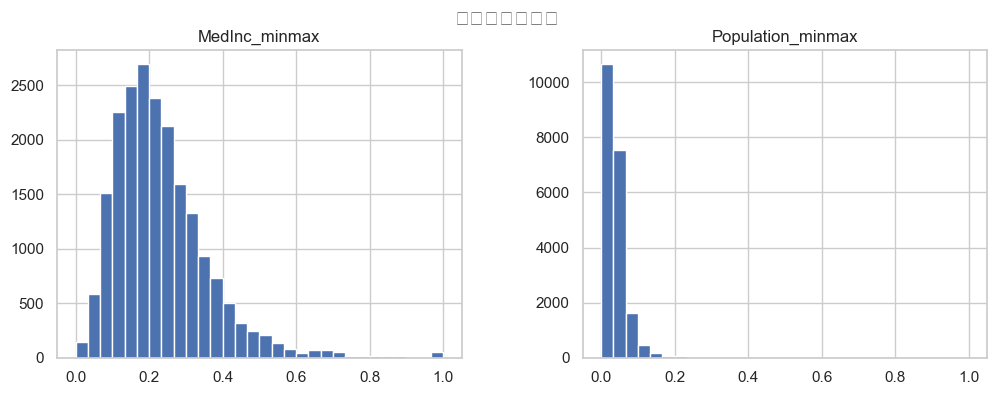

In [22]:
sample_df[['MedInc_minmax', 'Population_minmax']].hist(bins=30, figsize=(12, 4))
plt.suptitle('正規化後の分布')
plt.show()


### 標準化 (Standardization)

**平均 0, 分散 1** にスケーリングする手法。

$$
x_{\text{normalized}} = \frac{x - \mu}{\sigma}
$$

(`μ` は平均, `σ` は標準偏差)

- ✅ データの最大・最小が分からなくても適用できる
- ✅ 外れ値の影響を正規化より受けにくい (押しつぶされない)
- 実務では **正規化より標準化を使うことが多い**


In [23]:
standard = StandardScaler()
sample_df[['MedInc_std', 'Population_std']] = standard.fit_transform(sample_df[['MedInc', 'Population']])
sample_df.head()


,MedInc,Population,MedInc_minmax,Population_minmax,MedInc_std,Population_std
0,8.3252,322.0,0.539668,0.008941,2.344766,-0.974429
1,8.3014,2401.0,0.538027,0.067210,2.332238,0.861439
2,7.2574,496.0,0.466028,0.013818,1.782699,-0.820777
3,5.6431,558.0,0.354699,0.015555,0.932968,-0.766028
4,3.8462,565.0,0.230776,0.015752,-0.012881,-0.759847


In [24]:
print('標準化後の平均/分散:')
for c in ['MedInc_std', 'Population_std']:
    print(f'  {c}: mean={sample_df[c].mean():.6f}, var={sample_df[c].var():.6f}')


標準化後の平均/分散:
  MedInc_std: mean=0.000000, var=1.000048
  Population_std: mean=-0.000000, var=1.000048


/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 27161 (\N{CJK UNIFIED IDEOGRAPH-6A19}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21270 (\N{CJK UNIFIED IDEOGRAPH-5316}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24460 (\N{CJK UNIFIED IDEOGRAPH-5F8C}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/kenta.hoji.ea/.pyenv/versions/3.10.11/lib/python3.10/site

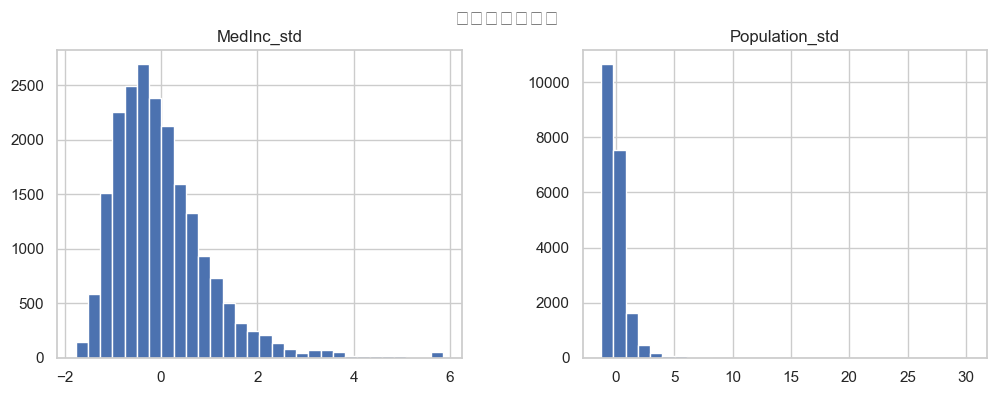

In [25]:
sample_df[['MedInc_std', 'Population_std']].hist(bins=30, figsize=(12, 4))
plt.suptitle('標準化後の分布')
plt.show()


### 重要: スケーラの `fit` は学習データだけで行う

検証データで `fit` してしまうと、検証データの情報が前処理に入り込み **リーク** になります。

```python
# 正しい流れ
scaler.fit(X_train)            # ← train だけで fit
X_train_s = scaler.transform(X_train)
X_test_s  = scaler.transform(X_test)   # ← test には transform のみ
```

`src.preprocessing.scale_features` はこの慣習に沿った実装になっています。


## ④ 特徴量生成 (Feature Engineering)

既存の列を組み合わせて **新しい列** を作る作業です。
ドメイン知識を活用するため、機械学習の精度向上に最も効きやすい工程と言われます。

### 今回の特徴量生成のアイデア

`Population` (人口) と `AveOccup` (平均世帯人口) から **世帯数** を計算できます:

> 平均世帯人口 = 人口 ÷ 世帯数
> よって **世帯数 = 人口 ÷ 平均世帯人口**

さらに `Household × AveRooms` で **合計居室数**、`Household × AveBedrms` で **合計寝室数** が求まります。


In [26]:
df_fe = features.add_household_features(df)
print('追加された列:', [c for c in df_fe.columns if c not in df.columns])
df_fe.head()


追加された列: ['Household', 'AllRooms', 'AllBedrms']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price,Household,AllRooms,AllBedrms
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526,126.0,880.0,129.0
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585,1138.0,7099.0,1106.0
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521,177.0,1467.0,190.0
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413,219.0,1274.0,235.0
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422,259.0,1627.0,280.0


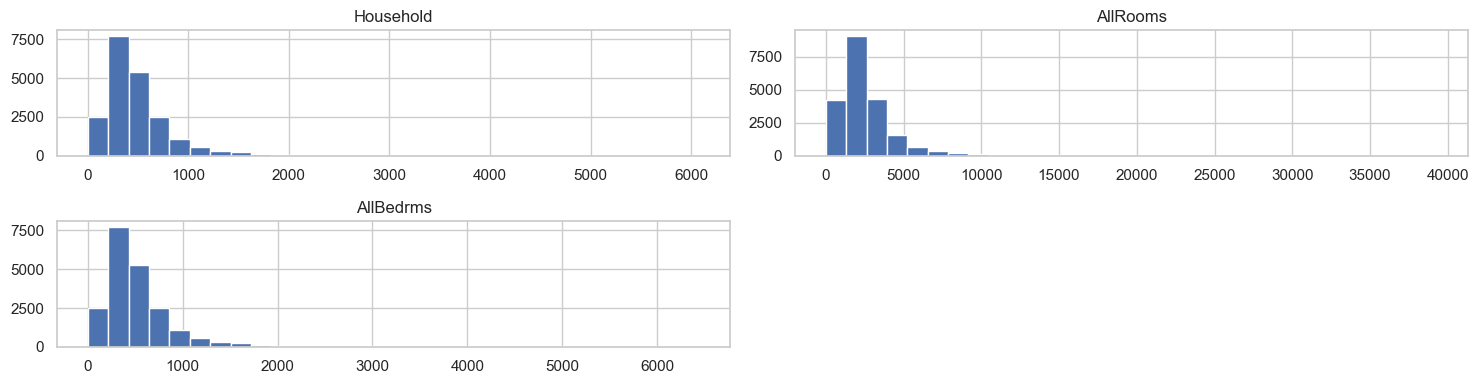

In [27]:
# 新しい列の分布をヒストグラムで確認
df_fe[['Household', 'AllRooms', 'AllBedrms']].hist(bins=30, figsize=(15, 4))
plt.tight_layout()
plt.show()


In [28]:
# 新しい特徴量と Price の相関
print('Price との相関 (新規列):')
print(df_fe[['Household', 'AllRooms', 'AllBedrms', 'Price']].corr()['Price'])


Price との相関 (新規列):
Household    0.065843
AllRooms     0.134153
AllBedrms    0.050594
Price        1.000000
Name: Price, dtype: float64


### 特徴量生成の他のアイデア

- **日付**: 年/月/曜日/祝日フラグ
- **テキスト**: 単語数/文字数/特定キーワードの出現回数
- **緯度経度**: 海岸線からの距離, 都市中心からの距離
- **集計**: ユーザーごとの過去 N 日合計, 月平均
- **差分・比率**: 列同士の引き算/割り算


## 前処理済みデータの保存

最終的にできた `df_fe` を `data/processed/` に保存します。
モデル学習のノートブック (`03_modeling.ipynb`) からはここから読み込みます。


In [29]:
saved_path = data_loader.save_processed(df_fe, 'california_housing_fe')
print('saved to:', saved_path)


saved to: /Users/kenta.hoji.ea/Desktop/pythonデータ分析/data_analysis_project/data/processed/california_housing_fe.csv


## まとめ

| 工程 | 主な手法 | 該当 src ファイル |
|-|-|-|
| 欠損値処理 | `drop` / `dropna` / `fillna` | `src/preprocessing.py: fill_missing` |
| エンコーディング | One-hot / Label | (今回は不要なので未実装) |
| スケーリング | StandardScaler / MinMaxScaler | `src/preprocessing.py: scale_features` |
| 特徴量生成 | ドメイン知識 + 数式 | `src/features.py: add_household_features` |

次は `03_modeling.ipynb` で **モデル学習** を行います。
